In [10]:
import numpy as np 
import pandas as pd

In [11]:
df=pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [12]:
df.shape

(1460, 81)

## Selecting only relevent features for prediction

In [13]:
features=[
    'GrLivArea',
    'BedroomAbvGr',
    'FullBath',
    'GarageCars',
    'TotalBsmtSF',
    'OverallQual'
]

target='SalePrice'
df=df[features+[target]]

In [14]:
print(df.isnull().sum())

GrLivArea       0
BedroomAbvGr    0
FullBath        0
GarageCars      0
TotalBsmtSF     0
OverallQual     0
SalePrice       0
dtype: int64


## So there are no missing values we need take care about

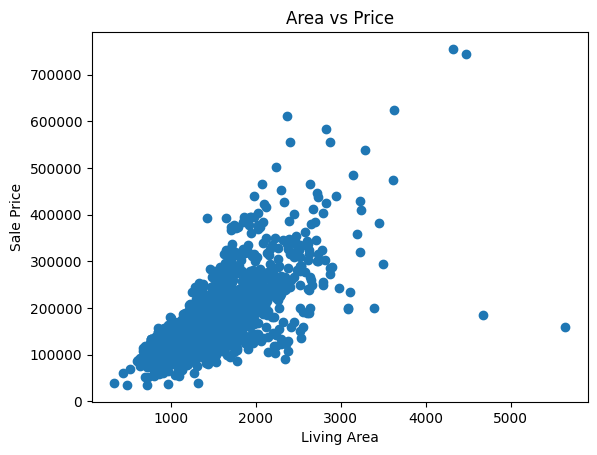

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['GrLivArea'],df['SalePrice'])
plt.xlabel("Living Area")
plt.ylabel("Sale Price")
plt.title("Area vs Price")
plt.show()

## The above scatter plot shows greater the Area greater is the price

In [17]:
from sklearn.model_selection import train_test_split

X=df[features]
y=df[target]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
from sklearn.metrics import mean_squared_error

# Linear Regression
y_pred_lr=lr.predict(X_test)
rmse_lr=np.sqrt(mean_squared_error(y_test,y_pred_lr))

# Random Forest
y_pred_rf=rf.predict(X_test)
rmse_rf=np.sqrt(mean_squared_error(y_test,y_pred_rf))

print("Linear Regression RMSE : ",rmse_lr)
print("Random Forest RMSE : ",rmse_rf)




Linear Regression RMSE :  39240.83928485172
Random Forest RMSE :  28642.500642285657


## Random Forest performed better because it captures non-linear relationships between house features and prices, unlike Linear Regression


In [21]:
import pickle

with open("house_price_model.pkl","wb") as f:
    pickle.dump(rf,f)